### Import

In [1]:
import os
import gc
import time
import scipy
import pickle 
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
import matplotlib.ticker as ticker
from matplotlib import pyplot as plt 

from sklearn import metrics
from sklearn.utils import resample
from sklearn.metrics import auc
from sklearn.metrics import f1_score 
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve

### Path

In [2]:
eicu_path_results  = "./Results/"
hirid_path_results = "../hirid/Results/"

### Read Results

In [3]:
eicu  = pd.read_csv(eicu_path_results  + 'LSTM_Result.csv')
hirid = pd.read_csv(hirid_path_results + 'LSTM_Result.csv')

In [5]:
eicu.head(3)

In [6]:
hirid.head(3)

### Select Hospitals

In [9]:
hosp1 = eicu[eicu.hospitalid == 338]
hosp2 = eicu[eicu.hospitalid == 252]
hosp3 = eicu[eicu.hospitalid == 167]
hosp4 = eicu[eicu.hospitalid == 420]
hosp5 = eicu[eicu.hospitalid == 188]
hosp6 = eicu[eicu.hospitalid == 443]
hosp7 = eicu[eicu.hospitalid == 300]
hosp8 = eicu[eicu.hospitalid == 199]

In [10]:
hosp1 = hosp1[['stay_id', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]
hosp2 = hosp2[['stay_id', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]
hosp3 = hosp3[['stay_id', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]
hosp4 = hosp4[['stay_id', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]
hosp5 = hosp5[['stay_id', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]
hosp6 = hosp6[['stay_id', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]
hosp7 = hosp7[['stay_id', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]
hosp8 = hosp8[['stay_id', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]
eicu  = eicu[['stay_id' , 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]
hirid = hirid[['stay_id', 'gender', 'age', 'LSTM_PREDICT_PROB', 'LSTM_PREDICT_LABEL', 'icu_expire_flag']]

hosp1.columns = ['stay_id', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'icu_expire_flag']
hosp2.columns = ['stay_id', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'icu_expire_flag']
hosp3.columns = ['stay_id', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'icu_expire_flag']
hosp4.columns = ['stay_id', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'icu_expire_flag']
hosp5.columns = ['stay_id', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'icu_expire_flag']
hosp6.columns = ['stay_id', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'icu_expire_flag']
hosp7.columns = ['stay_id', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'icu_expire_flag']
hosp8.columns = ['stay_id', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'icu_expire_flag']
eicu.columns  = ['stay_id', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'icu_expire_flag']
hirid.columns = ['stay_id', 'gender', 'age', 'PREDICT_PROB', 'PREDICT_LABEL', 'icu_expire_flag']

### ROC

In [11]:
def ROC_curve(true_label, prediction_prob):
    
    AUC = roc_auc_score(true_label, prediction_prob)
    fpr, tpr, roc_thresholds = roc_curve(true_label, prediction_prob)

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(fpr, tpr, color='darkorange', lw=1.2, label='Model (AUC = {:.2f})'.format(AUC))
    plt.plot([0, 1], [0, 1], color='navy', lw=1.2, linestyle='--', label='Random (AUC = 0.50)')
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('False Positive Rate', fontsize=8)
    plt.ylabel('True Positive Rate', fontsize=8)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [12]:
def get_roc_ci(y_true, y_score, ci_p= 1.96):
    
    auc_scores = []
    tprs = []
    mean_fpr = np.linspace(0, 1, 100)

    for j in range(1000):
        try:
            yte_true_b, yte_pred_b = resample(y_true, y_score, replace=True, random_state=j)
            fpr, tpr, _ = metrics.roc_curve(yte_true_b, yte_pred_b)
            tprs.append(np.interp(mean_fpr, fpr, tpr))
            tprs[-1][0] = 0.0
            auc_scores.append(metrics.roc_auc_score(yte_true_b, yte_pred_b))
            
        except Exception as e:
            continue
    
    mean_tpr = np.mean(tprs, axis=0)
    std_tpr = np.std(tprs, axis=0)
    
    tprs_upper = np.minimum(mean_tpr + ci_p * std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - ci_p * std_tpr, 0)
    
    auc = roc_auc_score(y_true, y_score)
    
    return mean_fpr, mean_tpr, tprs_lower, tprs_upper, auc

In [13]:
def plot_roc_with_ci(mean_fpr, mean_tpr, tprs_lower, tprs_upper, auc_ci):
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 6))
    
    plt.plot(mean_fpr, mean_tpr, color='blue', lw=2, label='Mean ROC (AUC = %0.2f)' % np.mean(auc_ci))
    plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=0.3)
    
    plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='red', label='Chance', alpha=0.8)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

In [14]:
mean_fpr, mean_tpr, tprs_lower, tprs_upper, auc_ci = get_roc_ci(eicu['icu_expire_flag'], eicu['PREDICT_PROB'])

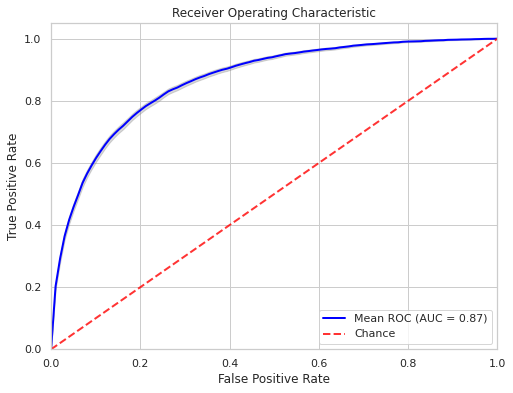

In [15]:
plot_roc_with_ci(mean_fpr, mean_tpr, tprs_lower, tprs_upper, auc_ci)

### Precision-Recall

In [16]:
def PRC_REC_curve(true_label, prediction_prob):
    
    AP = average_precision_score(true_label, prediction_prob)
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob)
    no_skill = len(true_label[true_label == 1]) / len(true_label) 

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(recall, precision, color='darkorange', lw=1.2, label='Model (AP = {:.2f})'.format(AP))
    plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill (AP = {:.2f})'.format(no_skill))
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('Recall', fontsize=8)
    plt.ylabel('Precision', fontsize=8)
    plt.title('Precision-Recall Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [17]:
def get_prc_ci(y_true, y_score, ci_p= 1.96):
    
    prc_scores = []
    precisions = []
    recalls = []
    thresholds = np.linspace(0, 1, 100)

    for j in range(1000):
        try:
            yte_true_b, yte_pred_b = resample(y_true, y_score, replace=True, random_state=j)
            precision, recall, _ = metrics.precision_recall_curve(yte_true_b, yte_pred_b)
            prc_score = metrics.auc(recall, precision)
            prc_scores.append(prc_score)
            interp_precision = np.interp(thresholds, recall[::-1], precision[::-1])
            precisions.append(interp_precision)
        except Exception as e:

            continue

    mean_precision = np.mean(precisions, axis=0)
    std_precision = np.std(precisions, axis=0)

    precision_upper = np.minimum(mean_precision + ci_p * std_precision, 1)
    precision_lower = np.maximum(mean_precision - ci_p * std_precision, 0)
    
    ap = average_precision_score(y_true, y_score)
    
    return thresholds, mean_precision, precision_lower, precision_upper, ap

In [18]:
def plot_prc_with_ci(thresholds, mean_precision, precision_lower, precision_upper, prc_ci):
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 6))

    plt.plot(thresholds, mean_precision, color='blue', lw=2, label='Mean PRC (AP = %0.2f)' % np.mean(prc_ci))
    plt.fill_between(thresholds, precision_lower, precision_upper, color='grey', alpha=0.3,)
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc="lower left")
    plt.show()

In [19]:
thresholds, mean_precision, precision_lower, precision_upper, prc_ci = get_prc_ci(eicu['icu_expire_flag'], eicu['PREDICT_PROB'])

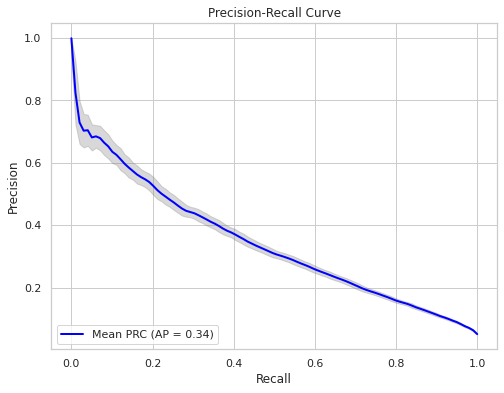

In [20]:
plot_prc_with_ci(thresholds, mean_precision, precision_lower, precision_upper, prc_ci)

### Performance Metrics

In [25]:
def Performance_Metrics(true_label, predicted_label, prediction_prob):
    
    TN, FP, FN, TP = confusion_matrix(true_label, predicted_label).ravel()

    ACC = (TP+TN)/(TP+FP+FN+TN)
    PRC = TP/(TP+FP)
    REC = TP/(TP+FN)
    F1M = (2*PRC*REC)/(PRC+REC)
    PPV = TP/(TP+FP)
    NPV = TN/(TN+FN)
    SEN = TP/(TP+FN)
    SPE = TN/(TN+FP) 
    FPR = FP/(FP+TN)
    FNR = FN/(TP+FN)
    FDR = FP/(TP+FP)

    AUC = roc_auc_score(true_label, prediction_prob)
    AP  = average_precision_score(true_label, prediction_prob)
    MCC = matthews_corrcoef(true_label, predicted_label)
    Brier = brier_score_loss(true_label, prediction_prob)
    
    print("ACC = " , np.round(ACC, 2)), print("PRC = " , np.round(PRC, 2))
    print("REC = " , np.round(REC, 2)), print("F1M = " , np.round(F1M, 2))
    print("PPV = " , np.round(PPV, 2)), print("NPV = " , np.round(NPV, 2))
    print("SEN = " , np.round(SEN, 2)), print("SPE = " , np.round(SPE, 2))
    print("FPR = " , np.round(FPR, 2)), print("FNR = " , np.round(FNR, 2))
    print("FDR = " , np.round(FDR, 2)), print("AUC = " , np.round(AUC, 2))
    print("AP  = " , np.round(AP,  2)), print("MCC = " , np.round(MCC, 2))
    print("Brier = " , np.round(Brier,  2))

In [26]:
def Performance_Metrics_CI(true_label, predicted_label, prediction_prob, n_bootstraps=1000, ci=95):
    
    metrics = {
        'ACC': [], 'PRC': [], 'REC': [], 'F1M': [], 'PPV': [],
        'NPV': [], 'SEN': [], 'SPE': [], 'FPR': [], 'FNR': [],
        'FDR': [], 'AUC': [], 'AP': [],  'MCC': [], 'BRR': []}
    
    for i in range(n_bootstraps):
        
        indices = resample(np.arange(len(true_label)), random_state=i)
        true_resampled = np.array(true_label)[indices]
        pred_resampled = np.array(predicted_label)[indices]
        prob_resampled = np.array(prediction_prob)[indices]
        
        TN, FP, FN, TP = confusion_matrix(true_resampled, pred_resampled).ravel()
        metrics['ACC'].append((TP + TN) / (TP + FP + FN + TN))
        metrics['PRC'].append(TP / (TP + FP) if TP + FP > 0 else 0)
        metrics['REC'].append(TP / (TP + FN) if TP + FN > 0 else 0)
        metrics['F1M'].append((2 * metrics['PRC'][-1] * metrics['REC'][-1]) / (metrics['PRC'][-1] + metrics['REC'][-1]) if metrics['PRC'][-1] + metrics['REC'][-1] > 0 else 0)
        metrics['PPV'].append(TP / (TP + FP) if TP + FP > 0 else 0)
        metrics['NPV'].append(TN / (TN + FN) if TN + FN > 0 else 0)
        metrics['SEN'].append(metrics['REC'][-1])
        metrics['SPE'].append(TN / (TN + FP) if TN + FP > 0 else 0)
        metrics['FPR'].append(FP / (FP + TN) if FP + TN > 0 else 0)
        metrics['FNR'].append(FN / (TP + FN) if TP + FN > 0 else 0)
        metrics['FDR'].append(FP / (TP + FP) if TP + FP > 0 else 0)
        metrics['AUC'].append(roc_auc_score(true_resampled, prob_resampled))
        metrics['AP'].append(average_precision_score(true_resampled, prob_resampled))
        metrics['MCC'].append(matthews_corrcoef(true_resampled, pred_resampled))
        metrics['BRR'].append(brier_score_loss(true_resampled, prob_resampled))

    ci_bounds = {}
    for key in metrics:
        lower = np.percentile(metrics[key], (100 - ci) / 2)
        upper = np.percentile(metrics[key], 100 - (100 - ci) / 2)
        mean  = np.mean(metrics[key])
        ci_bounds[key] = (mean, lower, upper)

    for metric, values in ci_bounds.items():
        print(f"{metric} = {values[0]:.3f} ({values[1]:.3f}-{values[2]:.3f})")

In [27]:
Performance_Metrics_CI(hosp1['icu_expire_flag'], hosp1['PREDICT_LABEL'], hosp1['PREDICT_PROB'])

ACC = 0.786 (0.772-0.800)
PRC = 0.163 (0.138-0.189)
REC = 0.774 (0.705-0.834)
F1M = 0.270 (0.231-0.305)
PPV = 0.163 (0.138-0.189)
NPV = 0.985 (0.980-0.989)
SEN = 0.774 (0.705-0.834)
SPE = 0.787 (0.772-0.801)
FPR = 0.213 (0.199-0.228)
FNR = 0.226 (0.166-0.295)
FDR = 0.837 (0.811-0.862)
AUC = 0.841 (0.808-0.872)
AP = 0.307 (0.235-0.383)
MCC = 0.288 (0.247-0.325)
BRR = 0.168 (0.160-0.176)


In [28]:
Performance_Metrics_CI(hosp2['icu_expire_flag'], hosp2['PREDICT_LABEL'], hosp2['PREDICT_PROB'])

ACC = 0.715 (0.696-0.732)
PRC = 0.210 (0.182-0.238)
REC = 0.860 (0.812-0.906)
F1M = 0.338 (0.299-0.374)
PPV = 0.210 (0.182-0.238)
NPV = 0.982 (0.975-0.988)
SEN = 0.860 (0.812-0.906)
SPE = 0.701 (0.682-0.719)
FPR = 0.299 (0.281-0.318)
FNR = 0.140 (0.094-0.188)
FDR = 0.790 (0.762-0.818)
AUC = 0.850 (0.823-0.875)
AP = 0.406 (0.341-0.473)
MCC = 0.328 (0.292-0.364)
BRR = 0.214 (0.204-0.225)


In [29]:
Performance_Metrics_CI(hosp3['icu_expire_flag'], hosp3['PREDICT_LABEL'], hosp3['PREDICT_PROB'])

ACC = 0.740 (0.722-0.758)
PRC = 0.193 (0.167-0.220)
REC = 0.832 (0.773-0.884)
F1M = 0.313 (0.277-0.350)
PPV = 0.193 (0.167-0.220)
NPV = 0.983 (0.976-0.988)
SEN = 0.832 (0.773-0.884)
SPE = 0.733 (0.714-0.751)
FPR = 0.267 (0.249-0.286)
FNR = 0.168 (0.116-0.227)
FDR = 0.807 (0.780-0.833)
AUC = 0.871 (0.844-0.895)
AP = 0.413 (0.338-0.486)
MCC = 0.315 (0.275-0.351)
BRR = 0.198 (0.187-0.208)


In [30]:
Performance_Metrics_CI(hosp4['icu_expire_flag'], hosp4['PREDICT_LABEL'], hosp4['PREDICT_PROB'])

ACC = 0.807 (0.795-0.820)
PRC = 0.283 (0.253-0.310)
REC = 0.775 (0.729-0.817)
F1M = 0.415 (0.379-0.447)
PPV = 0.283 (0.253-0.310)
NPV = 0.974 (0.968-0.979)
SEN = 0.775 (0.729-0.817)
SPE = 0.811 (0.797-0.824)
FPR = 0.189 (0.176-0.203)
FNR = 0.225 (0.183-0.271)
FDR = 0.717 (0.690-0.747)
AUC = 0.879 (0.861-0.897)
AP = 0.498 (0.439-0.556)
MCC = 0.388 (0.351-0.423)
BRR = 0.145 (0.138-0.152)


In [31]:
Performance_Metrics_CI(hosp5['icu_expire_flag'], hosp5['PREDICT_LABEL'], hosp5['PREDICT_PROB'])

ACC = 0.759 (0.743-0.776)
PRC = 0.192 (0.164-0.220)
REC = 0.842 (0.785-0.895)
F1M = 0.312 (0.273-0.350)
PPV = 0.192 (0.164-0.220)
NPV = 0.986 (0.980-0.991)
SEN = 0.842 (0.785-0.895)
SPE = 0.753 (0.737-0.771)
FPR = 0.247 (0.229-0.263)
FNR = 0.158 (0.105-0.215)
FDR = 0.808 (0.780-0.836)
AUC = 0.886 (0.861-0.909)
AP = 0.449 (0.373-0.524)
MCC = 0.325 (0.286-0.361)
BRR = 0.184 (0.174-0.192)


In [32]:
Performance_Metrics_CI(hosp6['icu_expire_flag'], hosp6['PREDICT_LABEL'], hosp6['PREDICT_PROB'])

ACC = 0.725 (0.709-0.741)
PRC = 0.191 (0.167-0.217)
REC = 0.903 (0.861-0.941)
F1M = 0.315 (0.281-0.351)
PPV = 0.191 (0.167-0.217)
NPV = 0.990 (0.985-0.994)
SEN = 0.903 (0.861-0.941)
SPE = 0.712 (0.694-0.728)
FPR = 0.288 (0.272-0.306)
FNR = 0.097 (0.059-0.139)
FDR = 0.809 (0.783-0.833)
AUC = 0.894 (0.872-0.915)
AP = 0.398 (0.332-0.465)
MCC = 0.333 (0.300-0.365)
BRR = 0.209 (0.199-0.219)


In [33]:
Performance_Metrics_CI(hosp7['icu_expire_flag'], hosp7['PREDICT_LABEL'], hosp7['PREDICT_PROB'])

ACC = 0.726 (0.709-0.744)
PRC = 0.158 (0.133-0.185)
REC = 0.902 (0.853-0.947)
F1M = 0.268 (0.231-0.309)
PPV = 0.158 (0.133-0.185)
NPV = 0.992 (0.988-0.996)
SEN = 0.902 (0.853-0.947)
SPE = 0.716 (0.698-0.734)
FPR = 0.284 (0.266-0.302)
FNR = 0.098 (0.053-0.147)
FDR = 0.842 (0.815-0.867)
AUC = 0.896 (0.875-0.917)
AP = 0.396 (0.315-0.483)
MCC = 0.304 (0.270-0.341)
BRR = 0.205 (0.195-0.214)


In [34]:
Performance_Metrics_CI(hosp8['icu_expire_flag'], hosp8['PREDICT_LABEL'], hosp8['PREDICT_PROB'])

ACC = 0.803 (0.788-0.818)
PRC = 0.217 (0.188-0.249)
REC = 0.872 (0.820-0.918)
F1M = 0.347 (0.307-0.389)
PPV = 0.217 (0.188-0.249)
NPV = 0.990 (0.986-0.994)
SEN = 0.872 (0.820-0.918)
SPE = 0.799 (0.783-0.814)
FPR = 0.201 (0.186-0.217)
FNR = 0.128 (0.082-0.180)
FDR = 0.783 (0.751-0.812)
AUC = 0.921 (0.902-0.938)
AP = 0.474 (0.396-0.555)
MCC = 0.372 (0.336-0.409)
BRR = 0.155 (0.146-0.162)


In [35]:
Performance_Metrics_CI(eicu['icu_expire_flag'], eicu['PREDICT_LABEL'], eicu['PREDICT_PROB'])

ACC = 0.770 (0.768-0.772)
PRC = 0.159 (0.156-0.163)
REC = 0.800 (0.791-0.809)
F1M = 0.266 (0.260-0.272)
PPV = 0.159 (0.156-0.163)
NPV = 0.986 (0.985-0.987)
SEN = 0.800 (0.791-0.809)
SPE = 0.768 (0.766-0.770)
FPR = 0.232 (0.230-0.234)
FNR = 0.200 (0.191-0.209)
FDR = 0.841 (0.837-0.844)
AUC = 0.865 (0.861-0.870)
AP = 0.344 (0.333-0.356)
MCC = 0.287 (0.282-0.293)
BRR = 0.178 (0.177-0.179)


In [36]:
Performance_Metrics_CI(hirid['icu_expire_flag'], hirid['PREDICT_LABEL'], hirid['PREDICT_PROB'])

ACC = 0.829 (0.823-0.834)
PRC = 0.290 (0.276-0.304)
REC = 0.800 (0.779-0.822)
F1M = 0.426 (0.409-0.443)
PPV = 0.290 (0.276-0.304)
NPV = 0.980 (0.977-0.982)
SEN = 0.800 (0.779-0.822)
SPE = 0.831 (0.825-0.836)
FPR = 0.169 (0.164-0.175)
FNR = 0.200 (0.178-0.221)
FDR = 0.710 (0.696-0.724)
AUC = 0.890 (0.881-0.899)
AP = 0.480 (0.450-0.510)
MCC = 0.413 (0.396-0.429)
BRR = 0.203 (0.200-0.207)


### Plotting Probability Distributions

In [37]:
def plot_kde(data, labels):
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6), dpi=80)
    sns.kdeplot(data[labels == 0], label='Survived', shade=True)
    sns.kdeplot(data[labels == 1], label='Deceased', shade=True)
    plt.title('Predicted Probability Distribution by Outcome', fontsize=14)
    plt.xlabel('Predicted Probability', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.legend()
    plt.show()

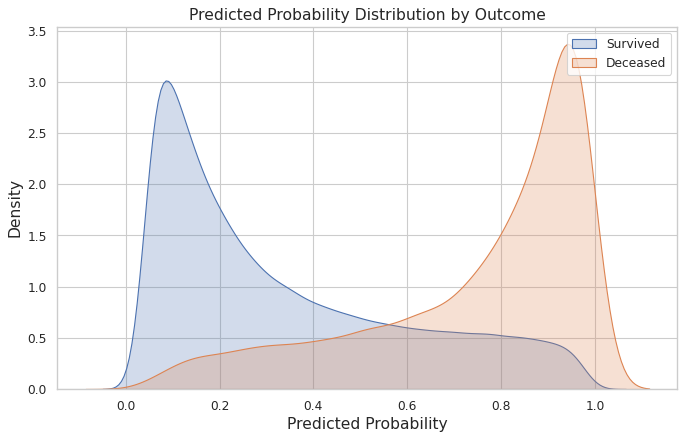

In [38]:
plot_kde(eicu['PREDICT_PROB'], eicu['icu_expire_flag'])

In [39]:
def plot_violin(data, labels):
    
    sns.set(style="whitegrid", context="talk")
    plt.figure(figsize=(10, 6), dpi=80)
    ax = sns.violinplot(x=labels, y=data, palette="muted", split=True)
    ax.set_xticklabels(['Survived', 'Deceased'])
    plt.title('Predicted Probability Distribution by Outcome', fontsize=14)
    plt.xlabel('Outcome', fontsize=14)
    plt.ylabel('Predicted Probability', fontsize=14)
    plt.show()

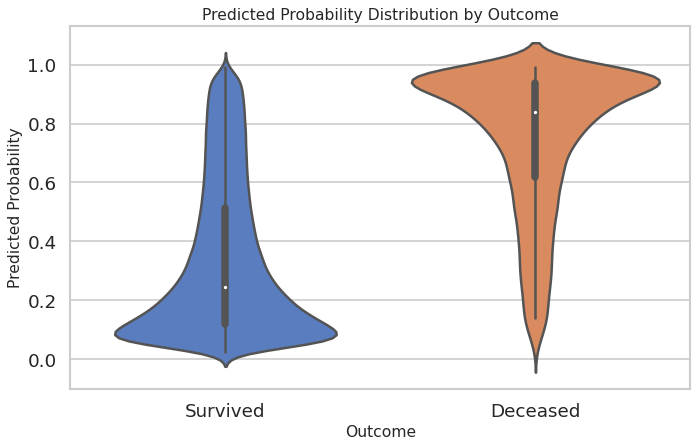

In [40]:
plot_violin(eicu['PREDICT_PROB'], eicu['icu_expire_flag'])

In [41]:
def plot_box(data, labels):
    
    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6), dpi=80)
    ax = sns.boxplot(x=labels, y=data, palette="muted")
    ax.set_xticklabels(['Survived', 'Deceased'], fontsize= 14)
    plt.title('Predicted Probability Distribution by Outcome', fontsize=14)
    plt.xlabel('Outcome', fontsize=14)
    plt.ylabel('Predicted Probability', fontsize=14)
    plt.show()

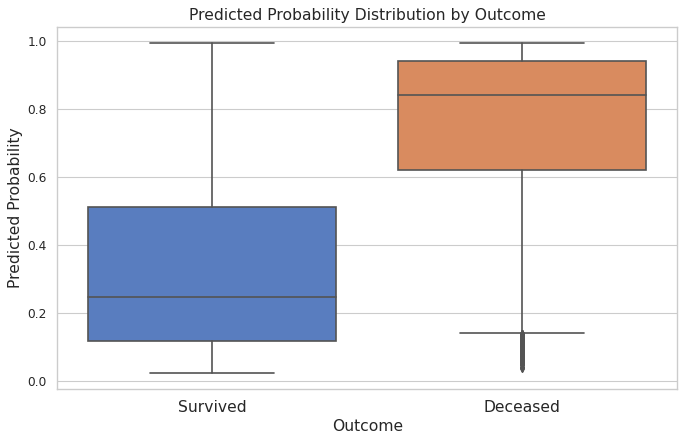

In [42]:
plot_box(eicu['PREDICT_PROB'], eicu['icu_expire_flag'])

### Plot ROC All

In [43]:
hosp1_mean_fpr, hosp1_mean_tpr, hosp1_tprs_lower, hosp1_tprs_upper, hosp1_auc_ci = get_roc_ci(hosp1['icu_expire_flag'], hosp1['PREDICT_PROB'], ci_p=1.64)
hosp2_mean_fpr, hosp2_mean_tpr, hosp2_tprs_lower, hosp2_tprs_upper, hosp2_auc_ci = get_roc_ci(hosp2['icu_expire_flag'], hosp2['PREDICT_PROB'], ci_p=1.64)
hosp3_mean_fpr, hosp3_mean_tpr, hosp3_tprs_lower, hosp3_tprs_upper, hosp3_auc_ci = get_roc_ci(hosp3['icu_expire_flag'], hosp3['PREDICT_PROB'], ci_p=1.64)
hosp4_mean_fpr, hosp4_mean_tpr, hosp4_tprs_lower, hosp4_tprs_upper, hosp4_auc_ci = get_roc_ci(hosp4['icu_expire_flag'], hosp4['PREDICT_PROB'], ci_p=1.64)
hosp5_mean_fpr, hosp5_mean_tpr, hosp5_tprs_lower, hosp5_tprs_upper, hosp5_auc_ci = get_roc_ci(hosp5['icu_expire_flag'], hosp5['PREDICT_PROB'], ci_p=1.64)
hosp6_mean_fpr, hosp6_mean_tpr, hosp6_tprs_lower, hosp6_tprs_upper, hosp6_auc_ci = get_roc_ci(hosp6['icu_expire_flag'], hosp6['PREDICT_PROB'], ci_p=1.64)
hosp7_mean_fpr, hosp7_mean_tpr, hosp7_tprs_lower, hosp7_tprs_upper, hosp7_auc_ci = get_roc_ci(hosp7['icu_expire_flag'], hosp7['PREDICT_PROB'], ci_p=1.64)
hosp8_mean_fpr, hosp8_mean_tpr, hosp8_tprs_lower, hosp8_tprs_upper, hosp8_auc_ci = get_roc_ci(hosp8['icu_expire_flag'], hosp8['PREDICT_PROB'], ci_p=1.64)
eicu_mean_fpr , eicu_mean_tpr , eicu_tprs_lower , eicu_tprs_upper , eicu_auc_ci  = get_roc_ci(eicu['icu_expire_flag'] , eicu[ 'PREDICT_PROB'], ci_p=1.96)
hirid_mean_fpr, hirid_mean_tpr, hirid_tprs_lower, hirid_tprs_upper, hirid_auc_ci = get_roc_ci(hirid['icu_expire_flag'], hirid['PREDICT_PROB'], ci_p=1.96)

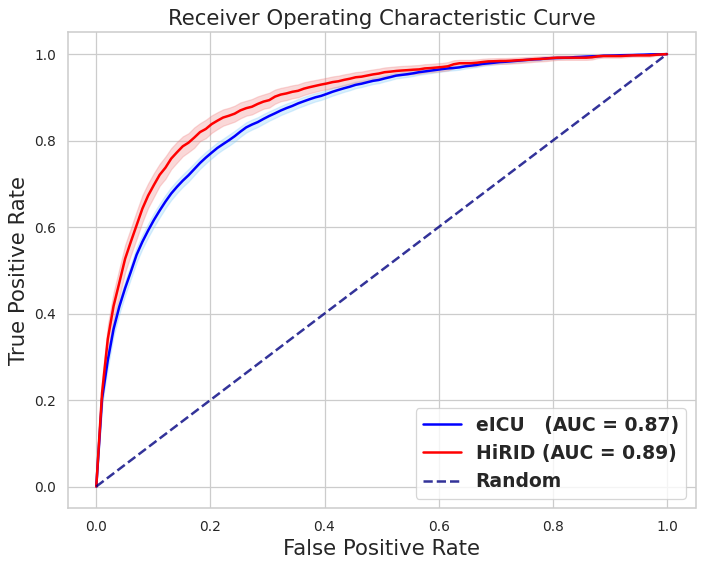

In [52]:
sns.set(style="whitegrid")
plt.figure(figsize=(9, 7), dpi=90)

plt.plot(eicu_mean_fpr, eicu_mean_tpr, color='blue', lw=2, label='eICU   (AUC = %0.2f)' % np.mean(eicu_auc_ci))
plt.fill_between(eicu_mean_fpr, eicu_tprs_lower, eicu_tprs_upper, color='lightskyblue', alpha=0.3)

plt.plot(hirid_mean_fpr, hirid_mean_tpr, color='red', lw=2, label='HiRID (AUC = %0.2f)' % np.mean(hirid_auc_ci))
plt.fill_between(hirid_mean_fpr, hirid_tprs_lower, hirid_tprs_upper, color='lightcoral', alpha=0.3)

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='navy', label='Random', alpha=0.8)

# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=17)
plt.ylabel('True Positive Rate', fontsize=17)
plt.title('Receiver Operating Characteristic Curve', fontsize=17)
# plt.legend(loc="lower right", fontsize=15)
legend = plt.legend(fontsize=15)  
for text in legend.get_texts():
    text.set_fontweight('bold')
plt.show()

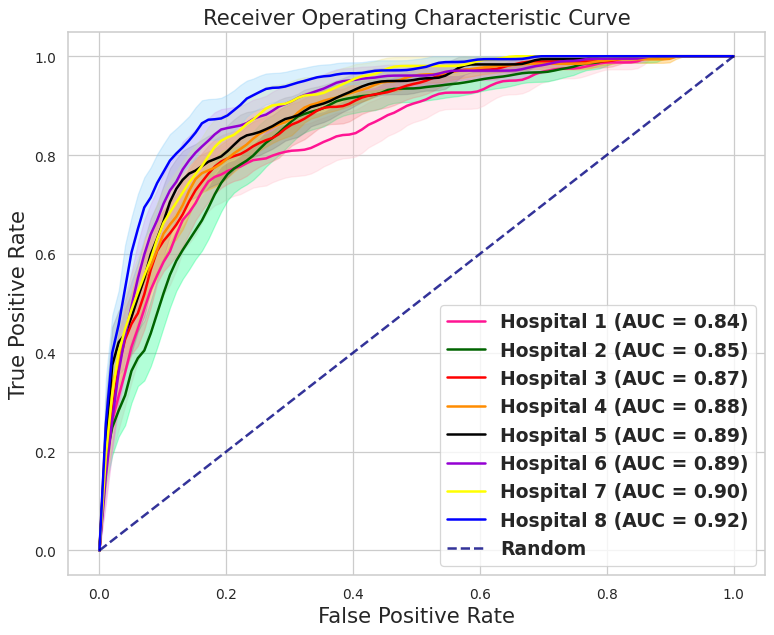

In [54]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 8), dpi=90)

plt.plot(hosp1_mean_fpr, hosp1_mean_tpr, color='deeppink', lw=2, label='Hospital 1 (AUC = %0.2f)' % np.mean(hosp1_auc_ci))
plt.fill_between(hosp1_mean_fpr, hosp1_tprs_lower, hosp1_tprs_upper, color='pink', alpha=0.3)

plt.plot(hosp2_mean_fpr, hosp2_mean_tpr, color='darkgreen', lw=2, label='Hospital 2 (AUC = %0.2f)' % np.mean(hosp2_auc_ci))
plt.fill_between(hosp2_mean_fpr, hosp2_tprs_lower, hosp2_tprs_upper, color='springgreen', alpha=0.3)

plt.plot(hosp3_mean_fpr, hosp3_mean_tpr, color='red', lw=2, label='Hospital 3 (AUC = %0.2f)' % np.mean(hosp3_auc_ci))
plt.fill_between(hosp3_mean_fpr, hosp3_tprs_lower, hosp3_tprs_upper, color='lightcoral', alpha=0.3)

plt.plot(hosp4_mean_fpr, hosp4_mean_tpr, color='darkorange', lw=2, label='Hospital 4 (AUC = %0.2f)' % np.mean(hosp4_auc_ci))
plt.fill_between(hosp4_mean_fpr, hosp4_tprs_lower, hosp4_tprs_upper, color='orange', alpha=0.3)

plt.plot(hosp5_mean_fpr, hosp5_mean_tpr, color='black', lw=2, label='Hospital 5 (AUC = %0.2f)' % np.mean(hosp5_auc_ci))
plt.fill_between(hosp5_mean_fpr, hosp5_tprs_lower, hosp5_tprs_upper, color='grey', alpha=0.3)

plt.plot(hosp6_mean_fpr, hosp6_mean_tpr, color='darkviolet', lw=2, label='Hospital 6 (AUC = %0.2f)' % np.mean(hosp6_auc_ci))
plt.fill_between(hosp6_mean_fpr, hosp6_tprs_lower, hosp6_tprs_upper, color='violet', alpha=0.3)

plt.plot(hosp7_mean_fpr, hosp7_mean_tpr, color='yellow', lw=2, label='Hospital 7 (AUC = %0.2f)' % np.mean(hosp7_auc_ci))
plt.fill_between(hosp7_mean_fpr, hosp7_tprs_lower, hosp7_tprs_upper, color='khaki', alpha=0.3)

plt.plot(hosp8_mean_fpr, hosp8_mean_tpr, color='blue', lw=2, label='Hospital 8 (AUC = %0.2f)' % np.mean(hosp8_auc_ci))
plt.fill_between(hosp8_mean_fpr, hosp8_tprs_lower, hosp8_tprs_upper, color='lightskyblue', alpha=0.3)

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='navy', label='Random', alpha=0.8)

# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=17)
plt.ylabel('True Positive Rate', fontsize=17)
plt.title('Receiver Operating Characteristic Curve', fontsize=17)
# plt.legend(loc="lower right", fontsize=14)
legend = plt.legend(fontsize=15)  
for text in legend.get_texts():
    text.set_fontweight('bold')
plt.show()

### Plot Precision-Recall All

In [46]:
hosp1_thresholds, hosp1_mean_precision, hosp1_precision_lower, hosp1_precision_upper, hosp1_prc_ci = get_prc_ci(hosp1['icu_expire_flag'], hosp1['PREDICT_PROB'], ci_p=1.15)
hosp2_thresholds, hosp2_mean_precision, hosp2_precision_lower, hosp2_precision_upper, hosp2_prc_ci = get_prc_ci(hosp2['icu_expire_flag'], hosp2['PREDICT_PROB'], ci_p=1.15)
hosp3_thresholds, hosp3_mean_precision, hosp3_precision_lower, hosp3_precision_upper, hosp3_prc_ci = get_prc_ci(hosp3['icu_expire_flag'], hosp3['PREDICT_PROB'], ci_p=1.15)
hosp4_thresholds, hosp4_mean_precision, hosp4_precision_lower, hosp4_precision_upper, hosp4_prc_ci = get_prc_ci(hosp4['icu_expire_flag'], hosp4['PREDICT_PROB'], ci_p=1.15)
hosp5_thresholds, hosp5_mean_precision, hosp5_precision_lower, hosp5_precision_upper, hosp5_prc_ci = get_prc_ci(hosp5['icu_expire_flag'], hosp5['PREDICT_PROB'], ci_p=1.15)
hosp6_thresholds, hosp6_mean_precision, hosp6_precision_lower, hosp6_precision_upper, hosp6_prc_ci = get_prc_ci(hosp6['icu_expire_flag'], hosp6['PREDICT_PROB'], ci_p=1.15)
hosp7_thresholds, hosp7_mean_precision, hosp7_precision_lower, hosp7_precision_upper, hosp7_prc_ci = get_prc_ci(hosp7['icu_expire_flag'], hosp7['PREDICT_PROB'], ci_p=1.15)
hosp8_thresholds, hosp8_mean_precision, hosp8_precision_lower, hosp8_precision_upper, hosp8_prc_ci = get_prc_ci(hosp8['icu_expire_flag'], hosp8['PREDICT_PROB'], ci_p=1.15)
eicu_thresholds , eicu_mean_precision , eicu_precision_lower , eicu_precision_upper , eicu_prc_ci  = get_prc_ci(eicu['icu_expire_flag'] , eicu[ 'PREDICT_PROB'], ci_p=2.56)
hirid_thresholds, hirid_mean_precision, hirid_precision_lower, hirid_precision_upper, hirid_prc_ci = get_prc_ci(hirid['icu_expire_flag'], hirid['PREDICT_PROB'], ci_p=1.96)

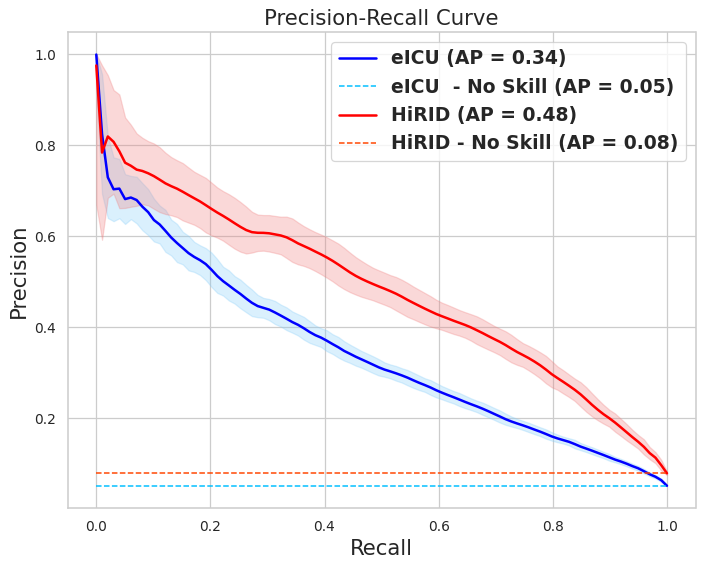

In [53]:
sns.set(style="whitegrid")
plt.figure(figsize=(9, 7), dpi=90)

plt.plot(eicu_thresholds, eicu_mean_precision, color='blue', lw=2, label='eICU (AP = %0.2f)' % np.mean((eicu_prc_ci)))
plt.fill_between(eicu_thresholds, eicu_precision_lower, eicu_precision_upper, color='lightskyblue', alpha=0.3,)

eicu_true_label  = np.array(eicu['icu_expire_flag'])
eicu_no_skill  = len(eicu_true_label[eicu_true_label == 1]) / len(eicu_true_label)
plt.plot([0, 1], [eicu_no_skill,  eicu_no_skill],  color='deepskyblue', lw=1.2, linestyle='--', label='eICU  - No Skill (AP = {:.2f})'.format(eicu_no_skill))

plt.plot(hirid_thresholds, hirid_mean_precision, color='red', lw=2, label='HiRID (AP = %0.2f)' % np.mean(hirid_prc_ci))
plt.fill_between(hirid_thresholds, hirid_precision_lower, hirid_precision_upper, color='lightcoral', alpha=0.3,)

hirid_true_label = np.array(hirid['icu_expire_flag'])
hirid_no_skill = len(hirid_true_label[hirid_true_label == 1]) / len(hirid_true_label)
plt.plot([0, 1], [hirid_no_skill, hirid_no_skill], color='orangered',   lw=1.2, linestyle='--', label='HiRID - No Skill (AP = {:.2f})'.format(hirid_no_skill))

plt.xlabel('Recall', fontsize=17)
plt.ylabel('Precision', fontsize=17)
plt.title('Precision-Recall Curve', fontsize=17)
# plt.legend(loc="best", fontsize=15)
legend = plt.legend(fontsize=15)  
for text in legend.get_texts():
    text.set_fontweight('bold')
plt.show()

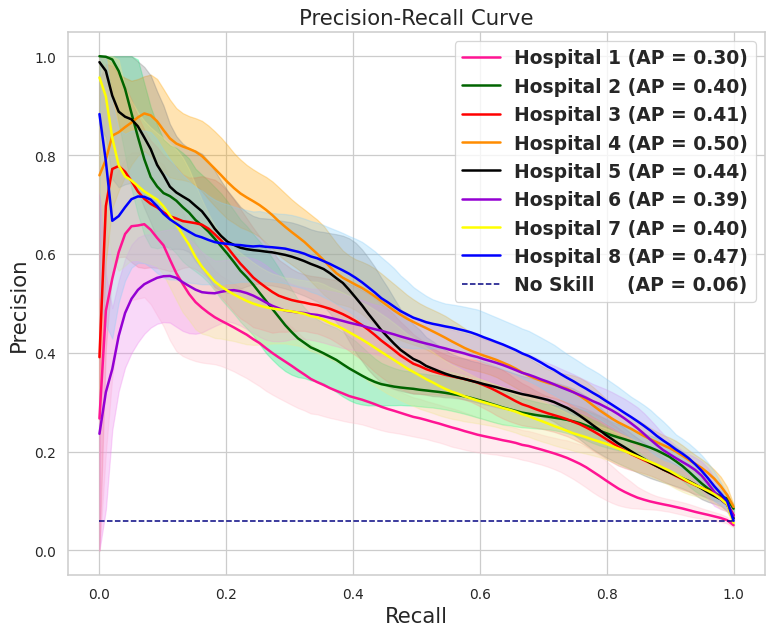

In [57]:
sns.set(style="whitegrid")
plt.figure(figsize=(10, 8), dpi=90)

plt.plot(hosp1_thresholds, hosp1_mean_precision, color='deeppink', lw=2, label='Hospital 1 (AP = %0.2f)' % np.mean(hosp1_prc_ci))
plt.fill_between(hosp1_thresholds, hosp1_precision_lower, hosp1_precision_upper, color='pink', alpha=0.3,)

plt.plot(hosp2_thresholds, hosp2_mean_precision, color='darkgreen', lw=2, label='Hospital 2 (AP = %0.2f)' % np.mean(hosp2_prc_ci))
plt.fill_between(hosp2_thresholds, hosp2_precision_lower, hosp2_precision_upper, color='springgreen', alpha=0.3,)

plt.plot(hosp3_thresholds, hosp3_mean_precision, color='red', lw=2, label='Hospital 3 (AP = %0.2f)' % np.mean(hosp3_prc_ci))
plt.fill_between(hosp3_thresholds, hosp3_precision_lower, hosp3_precision_upper, color='lightcoral', alpha=0.3,)

plt.plot(hosp4_thresholds, hosp4_mean_precision, color='darkorange', lw=2, label='Hospital 4 (AP = %0.2f)' % np.mean(hosp4_prc_ci))
plt.fill_between(hosp4_thresholds, hosp4_precision_lower, hosp4_precision_upper, color='orange', alpha=0.3,)

plt.plot(hosp5_thresholds, hosp5_mean_precision, color='black', lw=2, label='Hospital 5 (AP = %0.2f)' % np.mean(hosp5_prc_ci))
plt.fill_between(hosp5_thresholds, hosp5_precision_lower, hosp5_precision_upper, color='grey', alpha=0.3,)

plt.plot(hosp6_thresholds, hosp6_mean_precision, color='darkviolet', lw=2, label='Hospital 6 (AP = %0.2f)' % (np.mean(hosp6_prc_ci)))
plt.fill_between(hosp6_thresholds, hosp6_precision_lower, hosp6_precision_upper, color='violet', alpha=0.3,)

plt.plot(hosp7_thresholds, hosp7_mean_precision, color='yellow', lw=2, label='Hospital 7 (AP = %0.2f)' % (np.mean(hosp7_prc_ci)))
plt.fill_between(hosp7_thresholds, hosp7_precision_lower, hosp7_precision_upper, color='khaki', alpha=0.3,)

plt.plot(hosp8_thresholds, hosp8_mean_precision, color='blue', lw=2, label='Hospital 8 (AP = %0.2f)' % np.mean(hosp8_prc_ci))
plt.fill_between(hosp8_thresholds, hosp8_precision_lower, hosp8_precision_upper, color='lightskyblue', alpha=0.3,)

# true_label = np.array(lstm['icu_expire_flag'])
# no_skill = len(true_label[true_label == 1]) / len(true_label)
no_skill = 0.06
plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill     (AP = {:.2f})'.format(no_skill))

plt.xlabel('Recall', fontsize=17)
plt.ylabel('Precision', fontsize=17)
plt.title('Precision-Recall Curve', fontsize=17)
# plt.legend(loc="best", fontsize=14)
legend = plt.legend(fontsize=15)  
for text in legend.get_texts():
    text.set_fontweight('bold')
plt.show()